### Basic Chatbot with Langgraph(Graph API)

In [1]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

In [2]:
class State(TypedDict):
    messages: Annotated[list, add_messages]

In [3]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [9]:
from langchain_groq import ChatGroq
# from langchain.chat_models import init_chat_model

llm = ChatGroq(model= "llama-3.1-8b-instant")
# llm = init_chat_model("groq:llama-3.1-8b-instant")

In [10]:
# Node 
def chatbot(state: State):
    return {"messages": [llm.invoke(state["messages"])]}

In [11]:
graph_builder = StateGraph(State)

graph_builder.add_node("llmChatbot", chatbot)

graph_builder.add_edge(START, "llmChatbot")
graph_builder.add_edge("llmChatbot", END)

graph = graph_builder.compile()

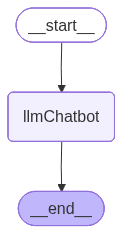

In [12]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [13]:
response = graph.invoke({"messages": "Hi"})

In [14]:
response["messages"]
# response["messages"][-1].content

[HumanMessage(content='Hi', additional_kwargs={}, response_metadata={}, id='6aaa7309-9102-490f-9054-b69539704ba7'),
 AIMessage(content="It's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 23, 'prompt_tokens': 36, 'total_tokens': 59, 'completion_time': 0.021775869, 'completion_tokens_details': None, 'prompt_time': 0.001595884, 'prompt_tokens_details': None, 'queue_time': 0.053068746, 'total_time': 0.023371753}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ed4dd-c8c7-7711-bd54-243de7ecdfd8-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 36, 'output_tokens': 23, 'total_tokens': 59})]

In [15]:
for event in graph.stream({"messages": "Hi, how are you?"}):
    # print(event)
    for value in event.values():
        print(value["messages"])


[AIMessage(content="I'm functioning properly, thank you for asking. What would you like to know or discuss today?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 21, 'prompt_tokens': 41, 'total_tokens': 62, 'completion_time': 0.032521916, 'completion_tokens_details': None, 'prompt_time': 0.001946661, 'prompt_tokens_details': None, 'queue_time': 0.048483899, 'total_time': 0.034468577}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ed4dd-ecf3-7d83-ad7e-353a2426d7e5-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 41, 'output_tokens': 21, 'total_tokens': 62})]


In [16]:
from langchain_tavily import TavilySearch

tool = TavilySearch(max_results = 2)
# tool.invoke("Friedrich Nietszche")

In [17]:
def multiply(a: float, b: float) -> float:
    """Multiply a and b

    Args:
        a (float): First number
        b (float): Second number

    Returns;
        (float): Returns a * b
    """
    return a * b

def add(a: float, b: float) -> float:
    """Add a and b

    Args:
        a (float): First number
        b (float): Second number

    Returns:
        (float): Returns a + b
    """
    return a + b

In [18]:
tools = [tool, add, multiply]
llmWithTools = llm.bind_tools(tools)

In [19]:
# llm
llmWithTools

_ChatModelBinding(bound=ChatGroq(metadata={'lc_versions': {'langchain-core': '1.4.7', 'langchain': '1.3.9'}}, output_version=None, profile={'name': 'Llama 3.1 8B Instant', 'release_date': '2024-07-23', 'last_updated': '2024-07-23', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 131072, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x7881595dd310>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x7881595dc230>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimiz

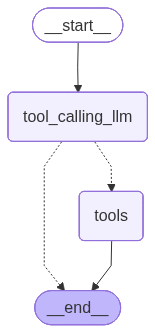

In [20]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from IPython.display import Image, display

def tool_calling_llm(state: State):
    return {"messages": [llmWithTools.invoke(state["messages"])]}

builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges("tool_calling_llm", tools_condition)
builder.add_edge("tools", END)

graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [25]:
response = graph.invoke({"messages": "What is the recent ai news and then multiply 5 by 2"})
#response
#response["messages"][-1].content
for message in response["messages"]:
    message.pretty_print()

================================ Human Message =================================

What is the recent ai news and then multiply 5 by 2
================================== Ai Message ==================================
Tool Calls:
  tavily_search (x94a56gpj)
 Call ID: x94a56gpj
  Args:
    query: recent ai news
    time_range: day
    topic: news
  multiply (8b3r4zjc3)
 Call ID: 8b3r4zjc3
  Args:
    a: 5
    b: 2
================================= Tool Message =================================
Name: tavily_search

{"query": "recent ai news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://apnews.com/article/nvidea-huang-artificial-intelligence-8334abcbc6ed8d3d7889b640ec6fa05b", "title": "AP Exclusive: Nvidia’s Jensen Huang says society needs ‘new social norms’ in the age of AI - AP News", "score": 0.61972505, "published_date": "Tue, 16 Jun 2026 20:06:08 GMT", "content": "+ Iran says the deal to end the war with the US requires Israel to withdraw from

### ReAct Agent

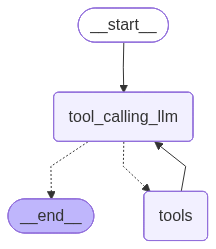

In [22]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from IPython.display import Image, display

def tool_calling_llm(state: State):
    return {"messages": [llmWithTools.invoke(state["messages"])]}

builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges("tool_calling_llm", tools_condition)
builder.add_edge("tools", "tool_calling_llm")

graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [24]:
response = graph.invoke({"messages": "What is the recent ai news, give a summary and then multiply 5 by 2"})
# response
# response["messages"][-1].content
for message in response["messages"]:
    message.pretty_print()

================================ Human Message =================================

What is the recent ai news, give a summary and then multiply 5 by 2
================================== Ai Message ==================================
Tool Calls:
  tavily_search (8pbjfx120)
 Call ID: 8pbjfx120
  Args:
    query: recent ai news
    time_range: day
    topic: news
  tavily_search (mthckf7y9)
 Call ID: mthckf7y9
  Args:
    query: recent ai news summary
    time_range: day
    topic: news
  multiply (m1pzhrfx7)
 Call ID: m1pzhrfx7
  Args:
    a: 5
    b: 2
================================= Tool Message =================================
Name: tavily_search

{"query": "recent ai news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://apnews.com/article/nvidea-huang-artificial-intelligence-8334abcbc6ed8d3d7889b640ec6fa05b", "title": "AP Exclusive: Nvidia’s Jensen Huang says society needs ‘new social norms’ in the age of AI - AP News", "score": 0.61972505, "

### ReAct Agent with Memory

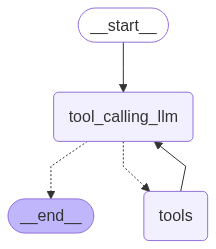

In [19]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langgraph.checkpoint.memory import MemorySaver
from IPython.display import Image, display

memory = MemorySaver()

def tool_calling_llm(state: State):
    return {"messages": [llmWithTools.invoke(state["messages"])]}

builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges("tool_calling_llm", tools_condition)
builder.add_edge("tools", "tool_calling_llm")

graph = builder.compile(checkpointer = memory)

display(Image(graph.get_graph().draw_mermaid_png()))

In [20]:
# THREAD_ID should be UNIQUE
config = {"configurable": {"thread_id": "1"}}
response = graph.invoke({"messages" : "I am working on Agentic AI"}, config = config)
for message in response["messages"]:
    message.pretty_print()

================================ Human Message =================================

I am working on Agentic AI
================================== Ai Message ==================================

I'm happy to help you with that. Can you provide more context or details about the specific task or problem you're trying to solve with Agentic AI? This will help me better understand your needs and provide more accurate guidance.


In [21]:
# THREAD_ID should be UNIQUE
config = {"configurable": {"thread_id": "1"}}
response = graph.invoke({"messages" : "What am I working on?"}, config = config)
for message in response["messages"]:
    message.pretty_print()

================================ Human Message =================================

I am working on Agentic AI
================================== Ai Message ==================================

I'm happy to help you with that. Can you provide more context or details about the specific task or problem you're trying to solve with Agentic AI? This will help me better understand your needs and provide more accurate guidance.
================================ Human Message =================================

What am I working on?
================================== Ai Message ==================================

You are working on implementing a conversation flow using the provided tool definitions and instructions. You need to generate a JSON string that matches the specified structure and schema, which will be used to call a tool or tools to answer a user's question.


### Stream Modes
stream() and astream_events()

### Stream Method

In [22]:
# Stream_Mode: updates - Appends messages, Streams updates to the state of graph after each node call
# for chunk in graph.stream({"messages": "Tell me the recent advances in AI and multiply 2 * 3"}, config = config, stream_mode = "updates"):
    # print(message)
# Stream_Mode: values - Prints all messages, Streams complete state of graph after each node call
for message in graph.stream({"messages": "Tell me the recent advances in AI and multiply 2 * 3"}, config = config, stream_mode = "values"):
    print(message)
# for message in response["messages"]:
    # message.pretty_print()

{'messages': [HumanMessage(content='I am working on Agentic AI', additional_kwargs={}, response_metadata={}, id='4754808a-2027-4d50-9d23-bb17d6734f61'), AIMessage(content="I'm happy to help you with that. Can you provide more context or details about the specific task or problem you're trying to solve with Agentic AI? This will help me better understand your needs and provide more accurate guidance.", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 47, 'prompt_tokens': 2390, 'total_tokens': 2437, 'completion_time': 0.051084951, 'prompt_time': 0.349979584, 'queue_time': 0.05073532399999997, 'total_time': 0.401064535}, 'model_name': 'llama3-8b-8192', 'system_fingerprint': 'fp_24ec19897b', 'finish_reason': 'stop', 'logprobs': None}, id='run--0e1c98dc-4c04-4de5-96f2-ada608849a9b-0', usage_metadata={'input_tokens': 2390, 'output_tokens': 47, 'total_tokens': 2437}), HumanMessage(content='What am I working on?', additional_kwargs={}, response_metadata={}, id='2b8

### AStream Method

In [24]:
config = {"configurable": {"thread_id": "2"}}

async for event in graph.astream_events({"messages": "Hello how are you?"}, config, version = "v2"):
    print(event)

{'event': 'on_chain_start', 'data': {'input': {'messages': 'Hello how are you?'}}, 'name': 'LangGraph', 'tags': [], 'run_id': '8b12007d-5b8d-404b-873f-784a932cd7a6', 'metadata': {'thread_id': '2'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='I like playing guitar', additional_kwargs={}, response_metadata={}, id='f4541ae0-b267-474f-ac3d-63c129706e60'), AIMessage(content='', additional_kwargs={'tool_calls': [{'index': 0, 'id': 'yq3zm1m8c', 'function': {'arguments': '{"query":"best guitar solo","search_depth":"advanced","time_range":"year","topic":"general"}', 'name': 'tavily_search'}, 'type': 'function'}]}, response_metadata={'finish_reason': 'tool_calls', 'model_name': 'llama3-8b-8192', 'system_fingerprint': 'fp_24ec19897b'}, id='run--bbc12f09-4679-41ac-bcd8-3db529150539', tool_calls=[{'name': 'tavily_search', 'args': {'query': 'best guitar solo', 'search_depth': 'advanced', 'time_range': 'year', 'topic': 'general'}, 'id': 'yq3zm1m